##Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("Flight_Fare.xlsx")

##View Dataset

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.shape

(10683, 11)

In [6]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


###Check Missing Values

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

###Remove Missing Values

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

###Check Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(220)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


##EDA(Exploratory Data Analysis)

###Airline Distribution

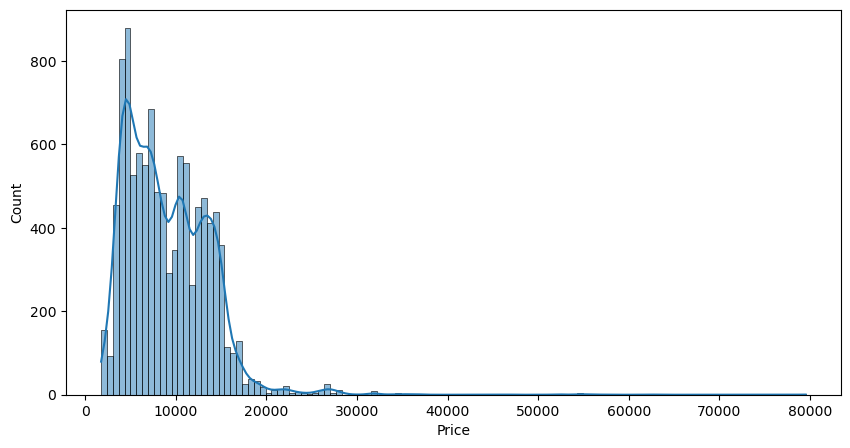

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], kde=True)
plt.show()

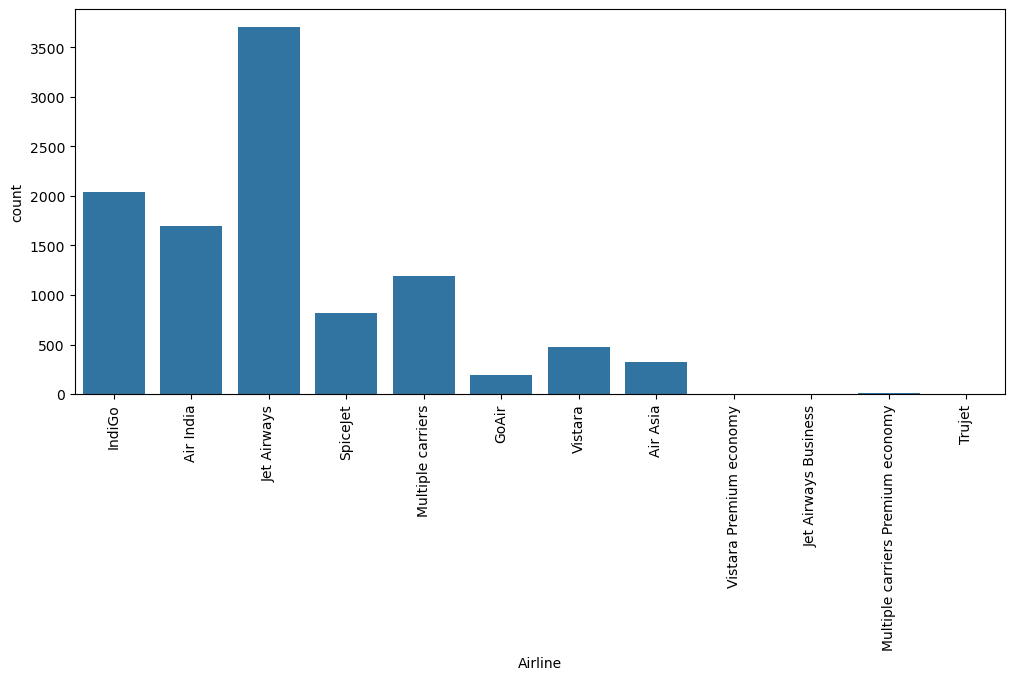

In [15]:
plt.figure(figsize=(12,5))
sns.countplot(x='Airline', data=df)
plt.xticks(rotation=90)
plt.show()

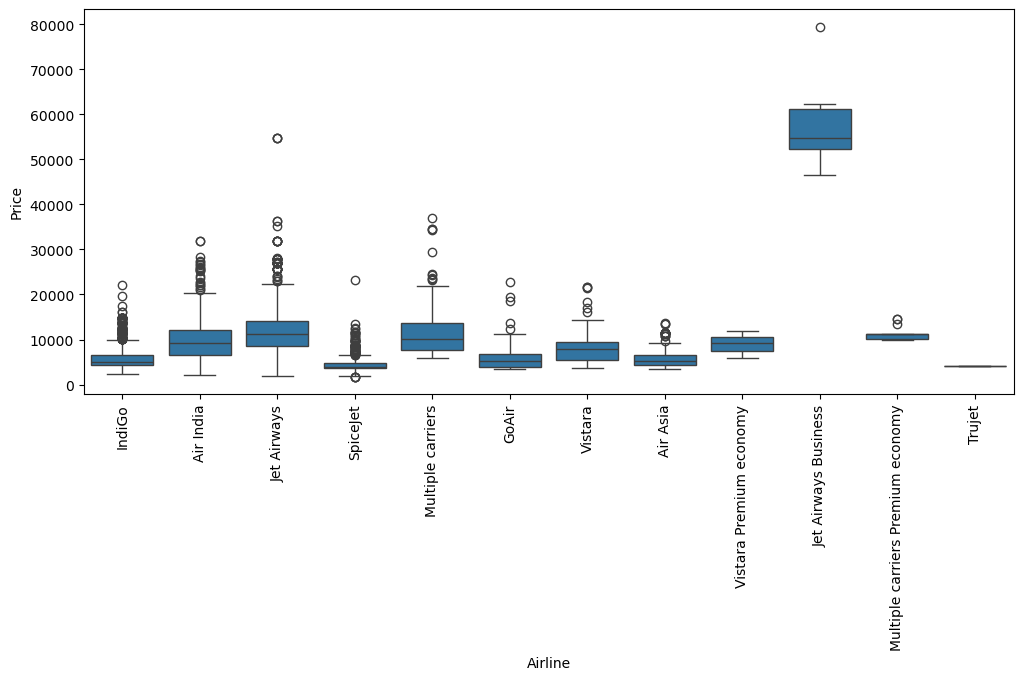

In [16]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)
plt.show()

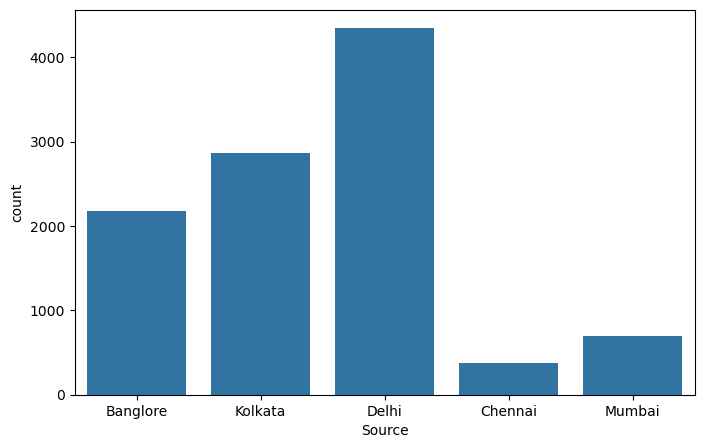

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Source', data=df)
plt.show()

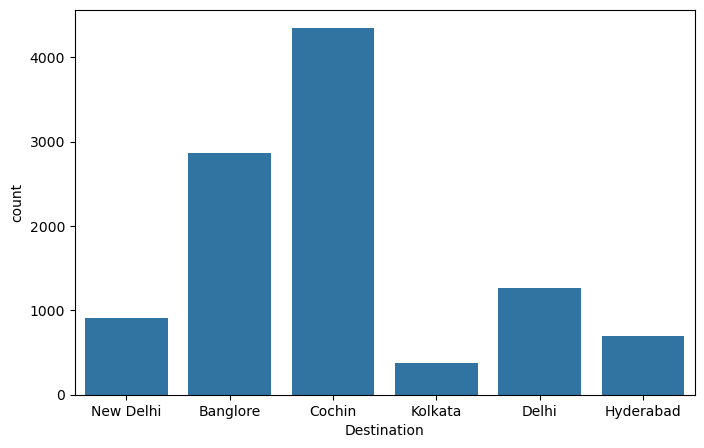

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Destination', data=df)
plt.show()

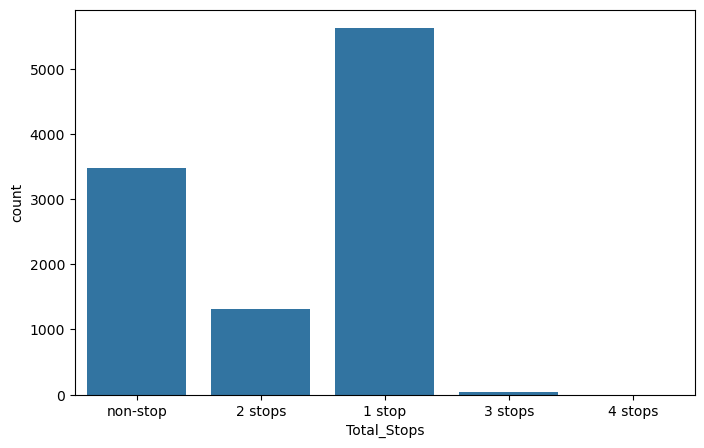

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Total_Stops', data=df)
plt.show()

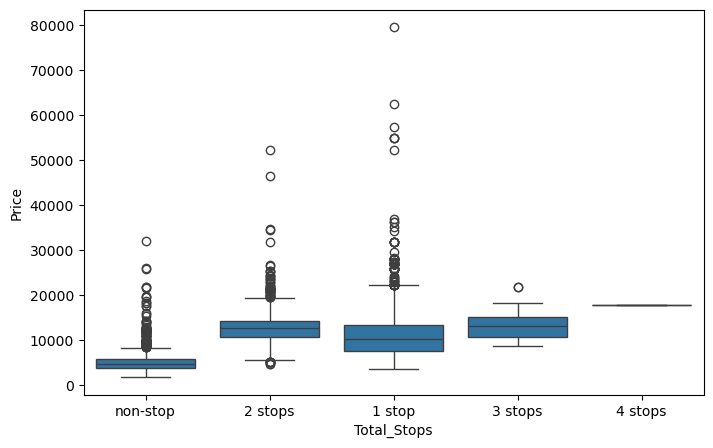

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.show()

###Convert Journey Date

In [21]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

In [22]:
df['Journey_Day'] = df['Date_of_Journey'].dt.day

df['Journey_Month'] = df['Date_of_Journey'].dt.month

In [23]:
df.drop('Date_of_Journey', axis=1, inplace=True)

###Convert Departure Time

In [24]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])

In [25]:
df['Dep_Hour'] = df['Dep_Time'].dt.hour

df['Dep_Min'] = df['Dep_Time'].dt.minute

In [26]:
df.drop('Dep_Time', axis=1, inplace=True)

In [27]:
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])

In [28]:
df['Arrival_Hour'] = df['Arrival_Time'].dt.hour

df['Arrival_Min'] = df['Arrival_Time'].dt.minute

In [29]:
df.drop('Arrival_Time', axis=1, inplace=True)

In [30]:
df['Duration'].head()

0    2h 50m
1    7h 25m
2       19h
3    5h 25m
4    4h 45m
Name: Duration, dtype: object

###Convert Duration

In [31]:
def duration_to_minutes(x):

    h = 0
    m = 0

    if 'h' in x:
        h = int(x.split('h')[0])

    if 'm' in x:
        m = int(x.split()[-1].replace('m',''))

    return h*60 + m

In [32]:
df['Duration_Minutes'] = df['Duration'].apply(duration_to_minutes)

In [33]:
df.drop('Duration', axis=1, inplace=True)

In [34]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [35]:
df['Total_Stops'] = df['Total_Stops'].map({
    'non-stop':0,
    '1 stop':1,
    '2 stops':2,
    '3 stops':3,
    '4 stops':4
})

In [36]:
df.drop(['Route','Additional_Info'], axis=1, inplace=True)

In [37]:
df = pd.get_dummies(df,
                    columns=['Airline',
                             'Source',
                             'Destination'],
                    drop_first=True)

In [38]:
df.head()

,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Minutes,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,170,False,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,1,5,5,50,13,15,445,True,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,6,9,25,4,25,1140,False,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,12,5,18,5,23,30,325,False,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,1,3,16,50,21,35,285,False,...,False,False,False,False,False,False,False,False,False,True


In [39]:
df.shape

(10462, 29)

###Correlation Heatmap

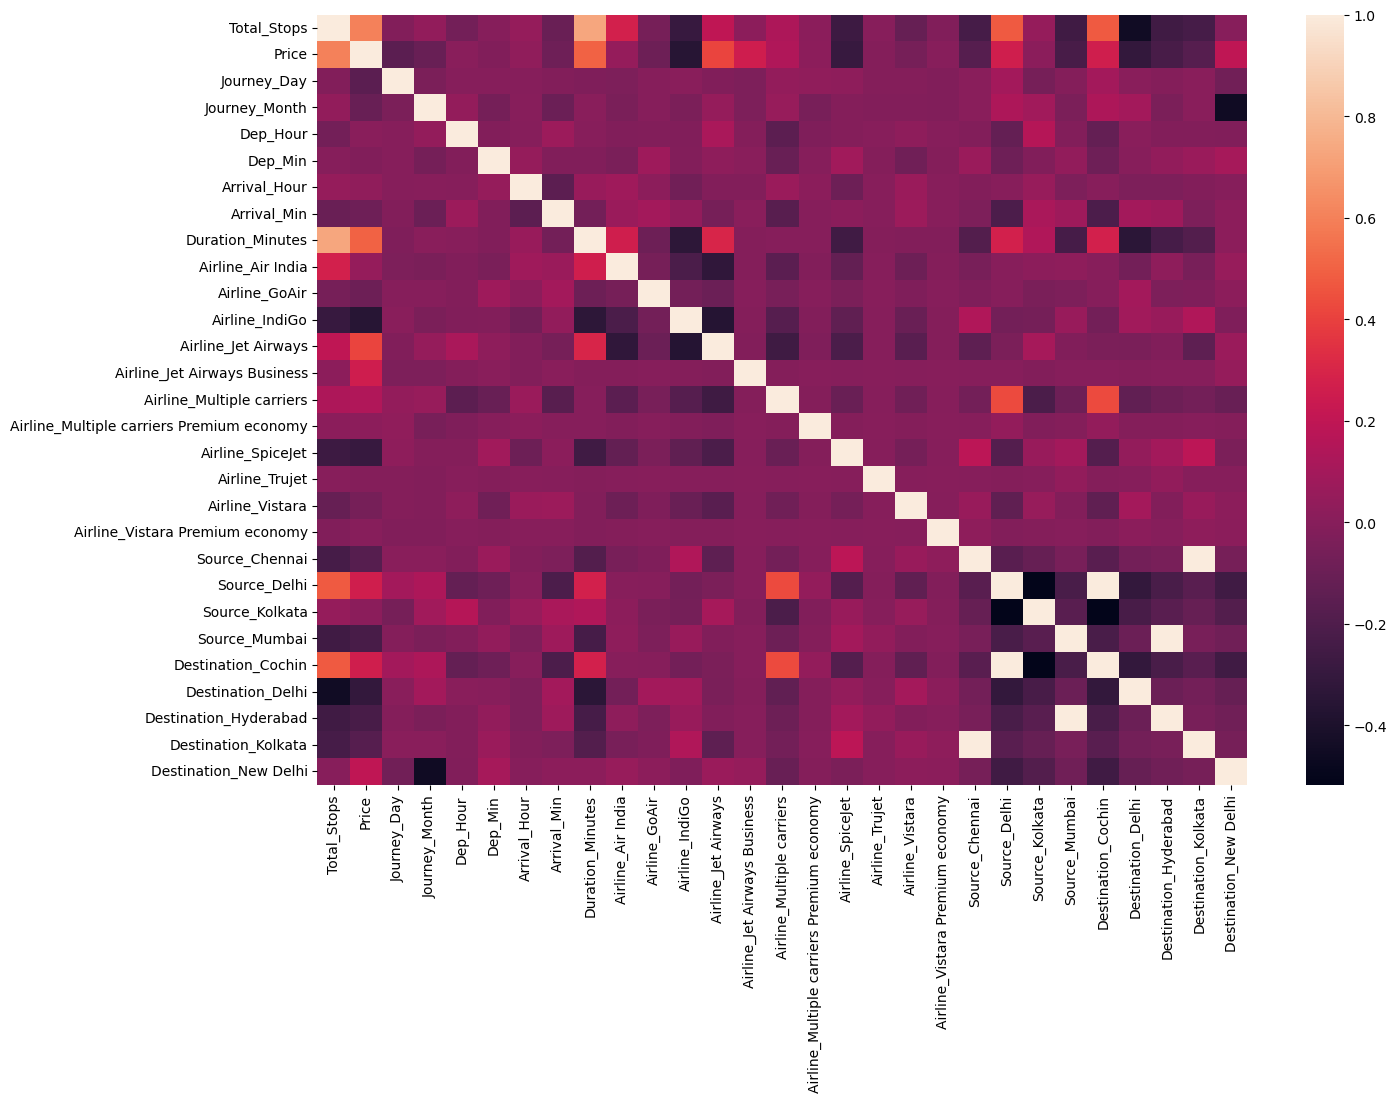

In [40]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr())
plt.show()

In [41]:
df.columns = df.columns.str.strip()

In [42]:
X = df.drop('Price', axis=1)

y = df['Price']

In [43]:
def time_category(x):
    if x < 6:
        return "Early Morning"
    elif x < 12:
        return "Morning"
    elif x < 18:
        return "Afternoon"
    else:
        return "Night"

In [44]:
df["Dep_Time_Category"] = df["Dep_Hour"].apply(time_category)

In [45]:
df = pd.get_dummies(df, columns=["Dep_Time_Category"], drop_first=True)

In [46]:
def duration_category(x):
    if x <= 180:
        return "Short"
    elif x <= 480:
        return "Medium"
    else:
        return "Long"

In [47]:
df["Duration_Category"] = df["Duration_Minutes"].apply(duration_category)

In [48]:
df = pd.get_dummies(df, columns=["Duration_Category"], drop_first=True)

In [49]:
df["Price_per_Hour"] = df["Price"] / (df["Duration_Minutes"] / 60)

In [50]:
df["Is_Peak_Departure"] = df["Dep_Hour"].apply(
    lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 20) else 0
)

In [51]:
df["Journey_Day_of_Week"] = pd.to_datetime(df["Journey_Day"]).apply(lambda x: x.weekday())
df["Is_Weekend"] = df["Journey_Day_of_Week"].apply(lambda x: 1 if x >= 5 else 0)

In [52]:
df["Price_per_Hour"] = df["Duration_Minutes"] / 60

In [53]:
print(df.columns)

Index(['Total_Stops', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Duration_Minutes',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi',
       'Dep_Time_Category_Early Morning', 'Dep_Time_Category_Morning',
       'Dep_Time_Category_Night', 'Duration_Category_Medium',
       'Duration_Category_Short', 'Price_per_Hour', 'Is_Peak_Departure',
       'Journey_Day_of_Week', 'Is_Weekend'],
      dtype='object')


In [54]:
df.columns = df.columns.str.strip()

In [55]:
[col for col in df.columns if "Journey" in col]

['Journey_Day', 'Journey_Month', 'Journey_Day_of_Week']

In [56]:
if "Date_of_Journey" in df.columns:
    df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"])
    df["Journey_Day"] = df["Date_of_Journey"].dt.day
    df["Journey_Month"] = df["Date_of_Journey"].dt.month

##Train Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[2796.88, -73.63,-391.71,...,-797.67, 38.63,1672.71]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](28,)","['Total_Stops','Journey_Day','Journey_Month',...,'Destination_Hyderabad', 'Destination_Kolkata','Destination_New Delhi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7034
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,24


In [60]:
lr_pred = lr.predict(X_test)

In [61]:
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

MAE : 1998.6393059377117
RMSE : 2945.7962357044935
R2 Score : 0.5838081325633984


In [62]:
from sklearn.tree import DecisionTreeRegressor

In [63]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [64]:
dt_pred = dt.predict(X_test)

In [65]:
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

MAE : 1383.0872352285394
RMSE : 2439.3263569570204
R2 Score : 0.7146170646423705


In [66]:
from sklearn.ensemble import RandomForestRegressor

In [67]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [68]:
rf_pred = rf.predict(X_test)

In [69]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 1168.9952375305324
RMSE : 1964.9648535216224
R2 Score : 0.8148184318714213


In [70]:
!pip install xgboost

In [71]:
from xgboost import XGBRegressor

In [72]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [73]:
xgb_pred = xgb.predict(X_test)

In [74]:
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, xgb_pred))
)
print("R2 Score :", r2_score(y_test, xgb_pred))

MAE : 1143.4158935546875
RMSE : 1823.9420906377484
R2 Score : 0.8404450416564941


In [75]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],

    "MAE":[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE
3,XGBoost,0.840445,1143.415894
2,Random Forest,0.814818,1168.995238
1,Decision Tree,0.714617,1383.087235
0,Linear Regression,0.583808,1998.639306


In [76]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

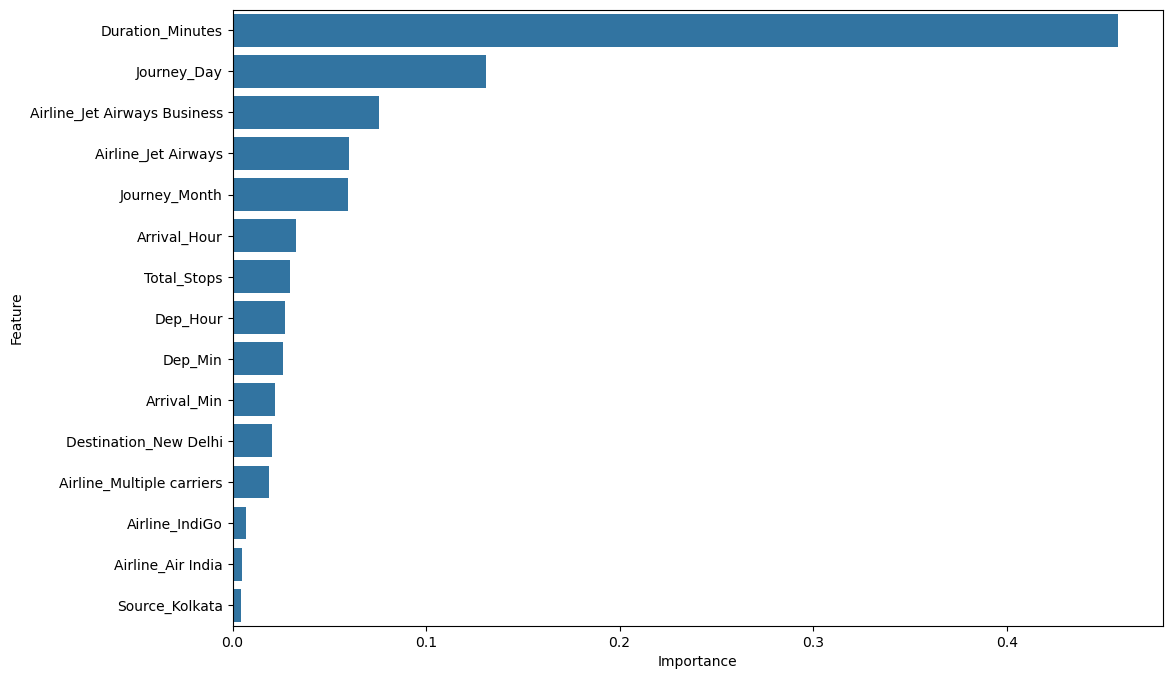

In [77]:
plt.figure(figsize=(12,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)
plt.show()

In [78]:
import pickle

In [79]:
pickle.dump(
    rf,
    open("flight_fare_model.pkl", "wb")
)

In [80]:
model = pickle.load(
    open("flight_fare_model.pkl", "rb")
)

##Model Comparision

In [81]:
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, dt_pred),
        mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, xgb_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1998.639306,8.677715e+06,2945.796236,0.583808
1,Decision Tree,1383.087235,5.950313e+06,2439.326357,0.714617
2,Random Forest,1168.995238,3.861087e+06,1964.964854,0.814818
3,XGBoost,1143.415894,3.326765e+06,1823.942091,0.840445


In [82]:
comparison["Rank"] = comparison["R2"].rank(
    ascending=False
)

comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2,Rank
3,XGBoost,1143.415894,3.326765e+06,1823.942091,0.840445,1.0
2,Random Forest,1168.995238,3.861087e+06,1964.964854,0.814818,2.0
1,Decision Tree,1383.087235,5.950313e+06,2439.326357,0.714617,3.0
0,Linear Regression,1998.639306,8.677715e+06,2945.796236,0.583808,4.0


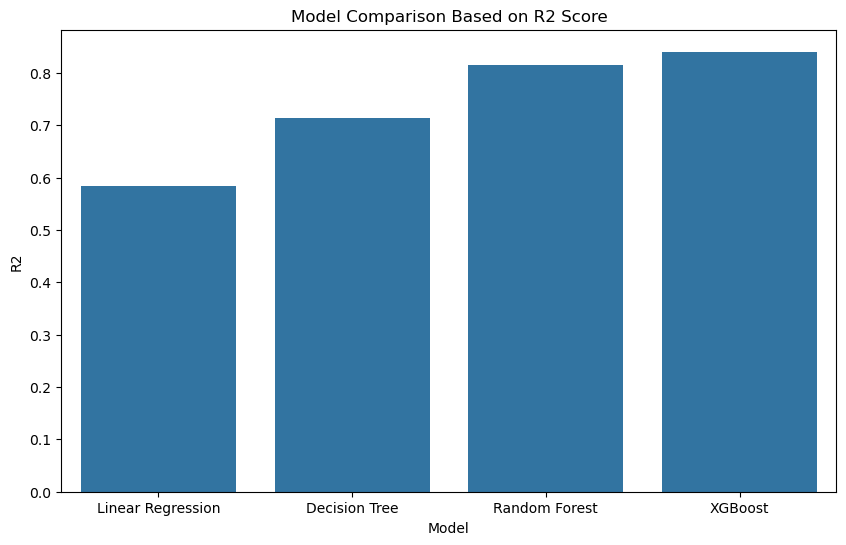

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R2",
    data=comparison
)

plt.title("Model Comparison Based on R2 Score")
plt.show()

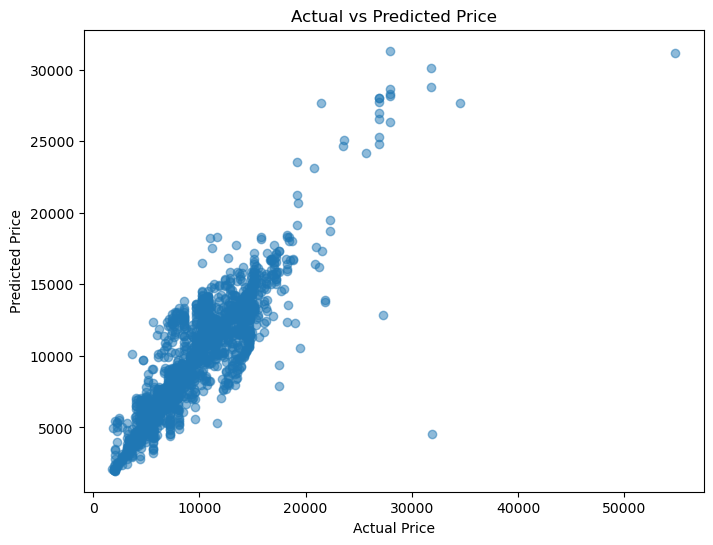

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")
plt.show()

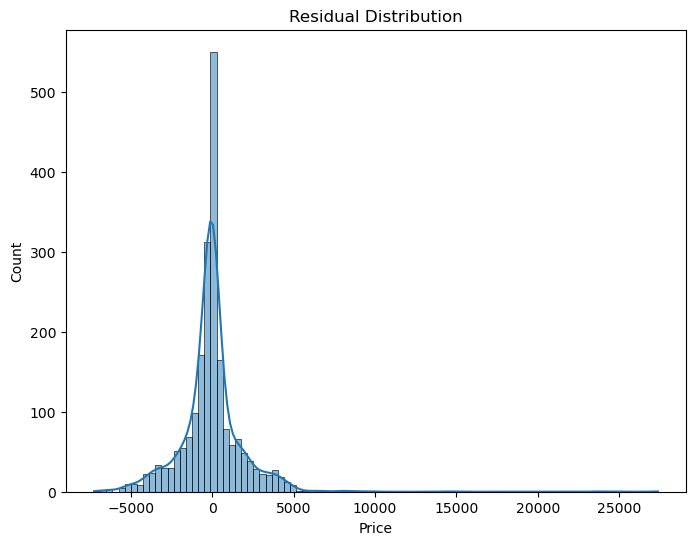

In [85]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")
plt.show()

In [86]:
from sklearn.model_selection import cross_val_score

In [87]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)

[0.81327616 0.80559861 0.84021607 0.81118343 0.78739409]


In [88]:
print("Average CV Score:",
      cv_scores.mean())

Average CV Score: 0.8115336739477058


###Hyperparameter Tuning

In [89]:
from sklearn.model_selection import GridSearchCV

In [90]:
params = {
    'n_estimators':[100,200,300],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

In [91]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls

In [92]:
print(grid.best_params_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}


In [93]:
print(grid.best_score_)

0.8139879435433884


In [94]:
report = pd.DataFrame({

    "Criteria":[
        "Interpretability",
        "Training Speed",
        "Accuracy",
        "Overfitting Risk",
        "Production Suitability"
    ],

    "Linear Regression":[
        "High",
        "Fast",
        "Low",
        "Low",
        "Medium"
    ],

    "Decision Tree":[
        "Medium",
        "Fast",
        "Medium",
        "High",
        "Medium"
    ],

    "Random Forest":[
        "Medium",
        "Medium",
        "High",
        "Low",
        "High"
    ],

    "XGBoost":[
        "Low",
        "Slow",
        "Very High",
        "Very Low",
        "Very High"
    ]
})

report

,Criteria,Linear Regression,Decision Tree,Random Forest,XGBoost
0,Interpretability,High,Medium,Medium,Low
1,Training Speed,Fast,Fast,Medium,Slow
2,Accuracy,Low,Medium,High,Very High
3,Overfitting Risk,Low,High,Low,Very Low
4,Production Suitability,Medium,Medium,High,Very High


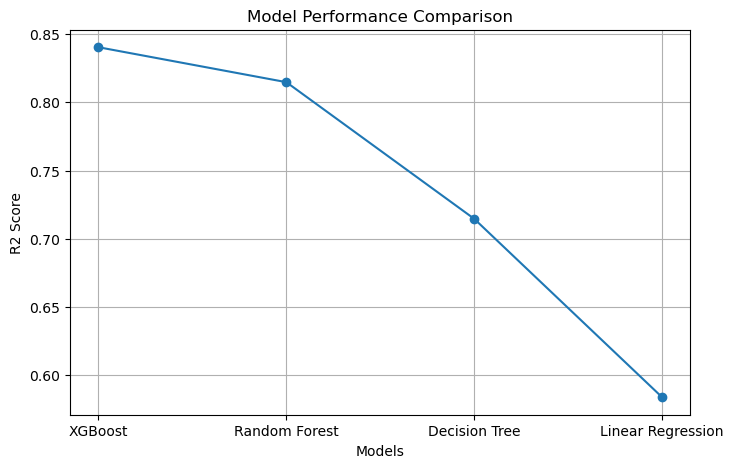

In [95]:
comparison_sorted = comparison.sort_values(
    by="R2",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.plot(
    comparison_sorted["Model"],
    comparison_sorted["R2"],
    marker='o'
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.grid(True)

plt.show()

*** 
RandomizedSearchCV

In [131]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best Score:
0.8432013034820557


In [132]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

In [135]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_outlier_removed = df[
    (df["Price"] >= lower) &
    (df["Price"] <= upper)
]

print("Original Shape :", df.shape)
print("After Outlier Removal :", df_outlier_removed.shape)

Original Shape : (10462, 38)
After Outlier Removal : (10368, 38)


In [136]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest"],
    "R2": [r2_score(y_test, pred)],
    "MAE": [mean_absolute_error(y_test, pred)],
    "RMSE": [mean_squared_error(y_test, pred)**0.5]
})

results.to_csv(
    "experiment_results.csv",
    index=False
)

print(results)

           Model        R2          MAE        RMSE
0  Random Forest  0.834493  1200.129883  1857.64885


In [133]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression

selector = SelectKBest(
    score_func=mutual_info_regression,
    k=15
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min',
       'Arrival_Hour', 'Arrival_Min', 'Duration_Minutes', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Source_Delhi', 'Source_Kolkata',
       'Destination_Cochin', 'Duration_Category_Short', 'Price_per_Hour'],
      dtype='object')


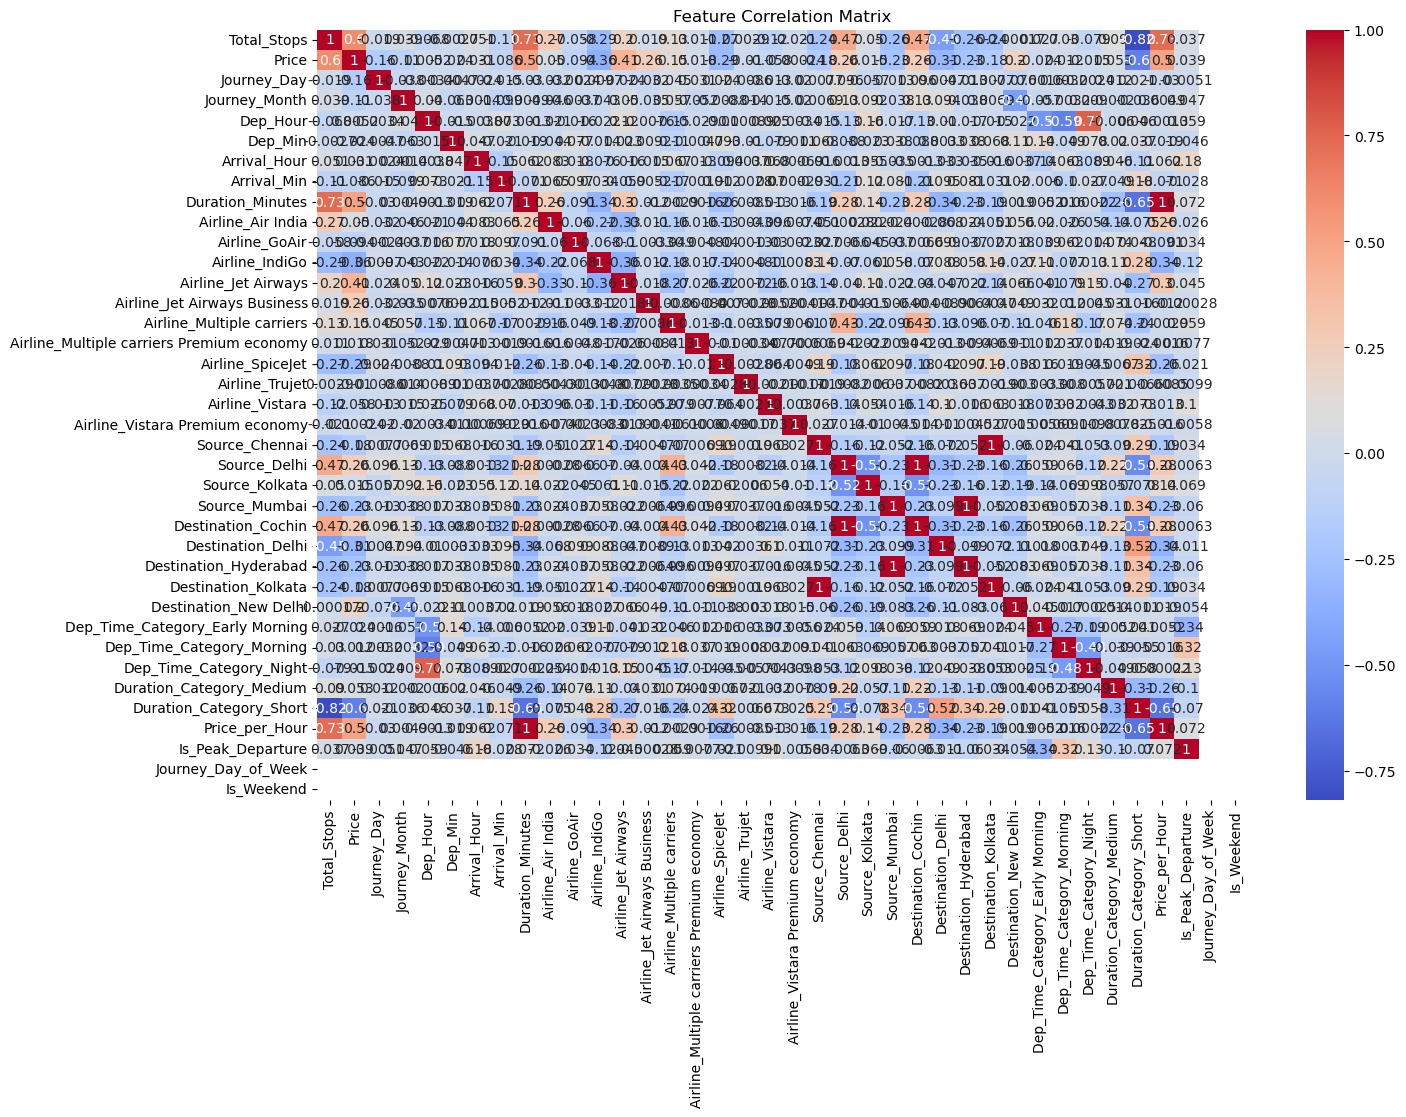

In [96]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [97]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

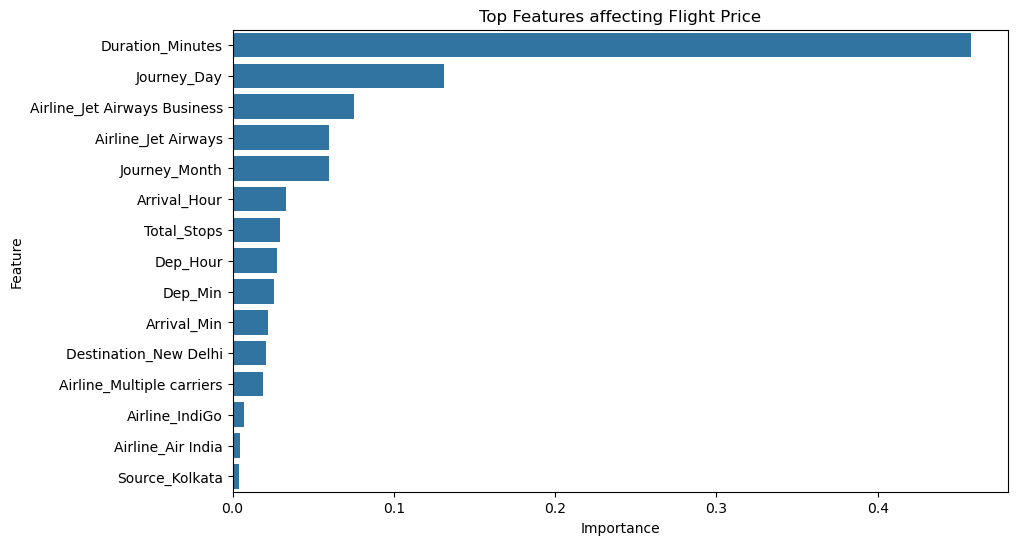

In [98]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_imp.head(15)
)

plt.title("Top Features affecting Flight Price")
plt.show()

In [99]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred,
})

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Abs_Error"] = abs(error_df["Error"])

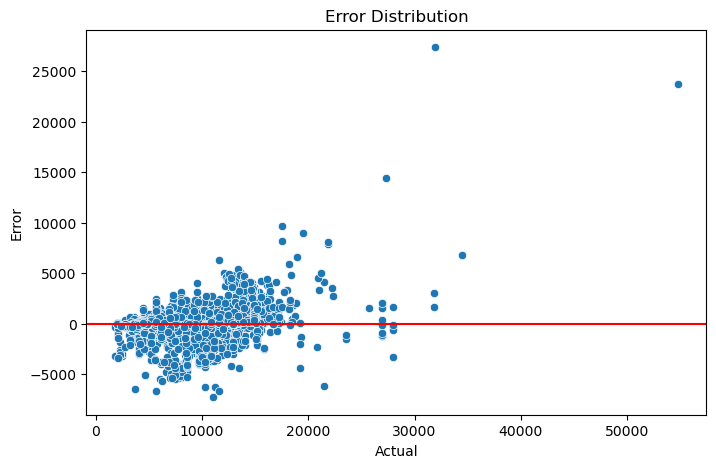

In [100]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=error_df["Actual"],
    y=error_df["Error"]
)

plt.axhline(0, color='red')

plt.title("Error Distribution")
plt.show()

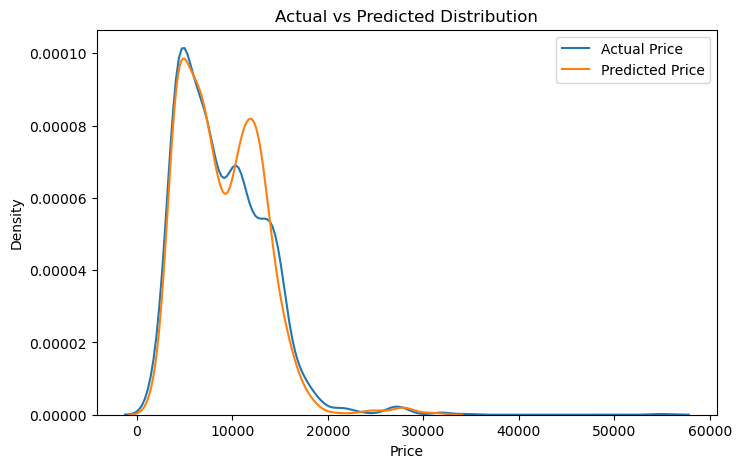

In [101]:
plt.figure(figsize=(8,5))

sns.kdeplot(y_test, label="Actual Price")
sns.kdeplot(rf_pred, label="Predicted Price")

plt.legend()
plt.title("Actual vs Predicted Distribution")
plt.show()

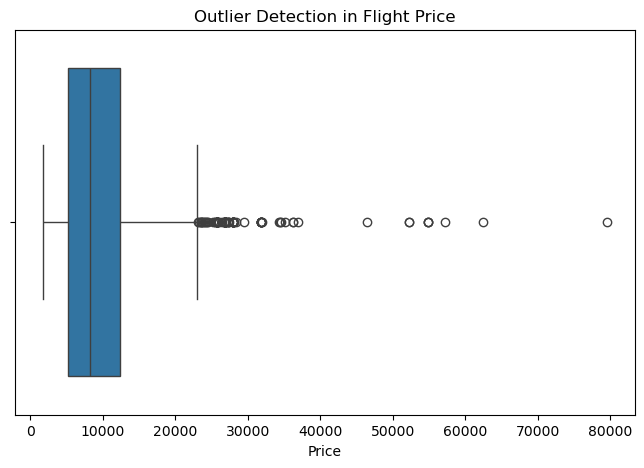

In [102]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])

plt.title("Outlier Detection in Flight Price")
plt.show()

In [103]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Linear", "Decision Tree", "Random Forest", "XGBoost"]

r2 = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, xgb_pred)
]

mae = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, dt_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, xgb_pred)
]

In [104]:
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

In [105]:
r2_n = normalize(np.array(r2))
mae_n = normalize(np.array(mae))

In [106]:
labels = ["R2 Score", "MAE"]
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

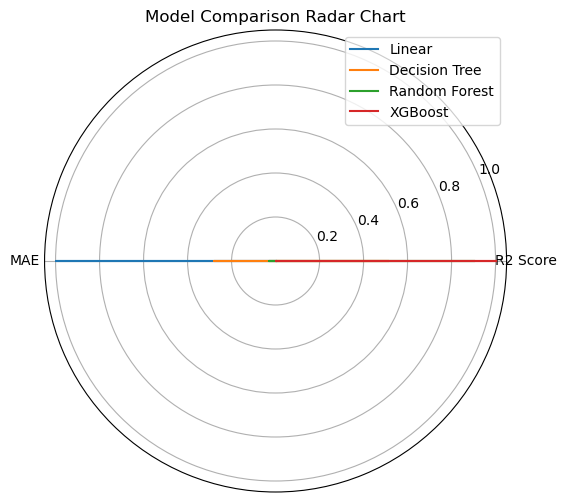

In [107]:
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111, polar=True)

for i, model in enumerate(models):

    values = [r2_n[i], mae_n[i]]
    values += values[:1]

    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title("Model Comparison Radar Chart")
plt.legend(loc="upper right")

plt.show()

In [108]:
def evaluate_model(name, model, X_test, y_test):

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    return [name, mae, rmse, r2]

In [109]:
results = []

results.append(evaluate_model("Linear Regression", lr, X_test, y_test))
results.append(evaluate_model("Decision Tree", dt, X_test, y_test))
results.append(evaluate_model("Random Forest", rf, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb, X_test, y_test))

In [110]:
comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1998.639306,2945.796236,0.583808
1,Decision Tree,1383.087235,2439.326357,0.714617
2,Random Forest,1168.995238,1964.964854,0.814818
3,XGBoost,1143.415894,1823.942091,0.840445


In [111]:
comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
3,XGBoost,1143.415894,1823.942091,0.840445
2,Random Forest,1168.995238,1964.964854,0.814818
1,Decision Tree,1383.087235,2439.326357,0.714617
0,Linear Regression,1998.639306,2945.796236,0.583808


In [112]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("🏆 Best Model:")
print(best_model)

🏆 Best Model:
Model           XGBoost
MAE         1143.415894
RMSE        1823.942091
R2 Score       0.840445
Name: 3, dtype: object


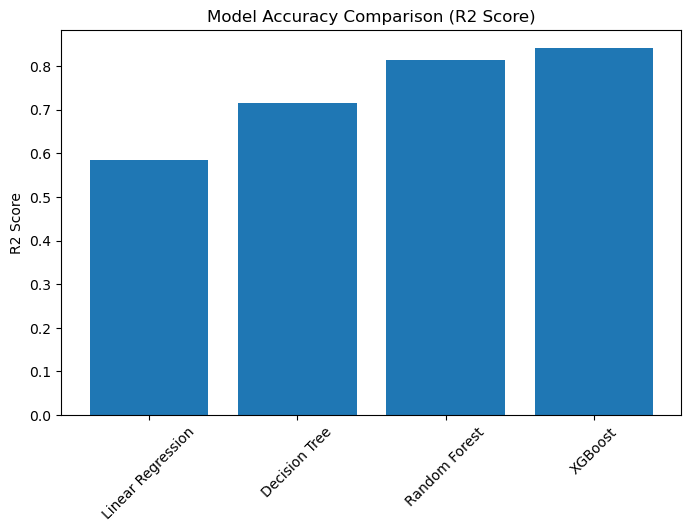

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Model Accuracy Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)

plt.show()

In [137]:
import pandas as pd
from datetime import datetime

log = pd.DataFrame({
    "Timestamp": [datetime.now()],
    "Actual": [y_test.iloc[0]],
    "Predicted": [pred[0]]
})

log.to_csv(
    "prediction_logs.csv",
    mode='a',
    header=False,
    index=False
)

print("Prediction Logged")

Prediction Logged


In [138]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
0.8432013034820557


***
Evaluate the predicted fare and the actual fare

In [141]:
y_pred = random_search.best_estimator_.predict(X_test)

print("Predicted Fare:", y_pred[0])
print("Actual Fare:", y_test.iloc[0])

Predicted Fare: 14522.968
Actual Fare: 17996


In [144]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nColumns in X_train but not X_test:")
print(set(X_train.columns) - set(X_test.columns))

print("\nColumns in X_test but not X_train:")
print(set(X_test.columns) - set(X_train.columns))

X_train: (8369, 37)
X_test: (2093, 37)

Columns in X_train but not X_test:
set()

Columns in X_test but not X_train:
set()


In [146]:
print("Predicted Fare:", xgb_pred[0])
print("Actual Fare:", y_test.iloc[0])

Predicted Fare: 14415.188
Actual Fare: 17996


In [147]:
print("Predicted Fare:", rf_pred[0])
print("Actual Fare:", y_test.iloc[0])

Predicted Fare: 14683.549749999998
Actual Fare: 17996


In [148]:
print(best_model)

Model           XGBoost
MAE         1143.415894
RMSE        1823.942091
R2 Score       0.840445
Name: 3, dtype: object


In [150]:
results = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": xgb_pred
})

results.head(10)

,Actual Fare,Predicted Fare
0,17996,14415.188477
1,3873,3868.599365
2,4462,4293.818848
3,2228,4309.739746
4,4991,4300.729004
5,7670,8003.825684
6,14086,17849.927734
7,6386,6091.978027
8,6628,6929.586914
9,6934,6162.422852


In [151]:
print(comparison_sorted)

               Model          MAE           MSE         RMSE        R2  Rank
3            XGBoost  1143.415894  3.326765e+06  1823.942091  0.840445   1.0
2      Random Forest  1168.995238  3.861087e+06  1964.964854  0.814818   2.0
1      Decision Tree  1383.087235  5.950313e+06  2439.326357  0.714617   3.0
0  Linear Regression  1998.639306  8.677715e+06  2945.796236  0.583808   4.0


In [152]:
best_model = xgb

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

print("Predicted Fare:", best_pred[0])
print("Actual Fare:", y_test.iloc[0])

Predicted Fare: 14560.567
Actual Fare: 17996


In [153]:
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

best_model_name = comparison_sorted.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost
